# 01. 국내채권(PRBD01N001) EDA

스냅샷 파일 기준일: **2026-07-11** / 원본 42,394행 × 40컬럼

목적: 온톨로지 클래스·속성 설계와 RAG QA의 "답변 가능 범위"를 확정하기 위한 실측.
모든 CSV는 `dtype=str, keep_default_na=False`로 읽고 **빈 문자열 `''`을 결측**으로 취급한다.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

ROOT = Path.cwd()
while not (ROOT / "data" / "csv").exists():
    ROOT = ROOT.parent
CSV = ROOT / "data" / "csv"
SNAPSHOT = pd.Timestamp("2026-07-11")

df = pd.read_csv(CSV / "PRBD01N001_bond_kr_master_20260711.csv", dtype=str, keep_default_na=False)
schema = pd.read_csv(CSV / "PRBD01N001_bond_kr_schema_20260711.csv", dtype=str, keep_default_na=False)
axis = pd.read_csv(CSV / "PRBD01N001_bond_kr_axis_sample_20260711.csv", dtype=str, keep_default_na=False)
print(df.shape, schema.shape, axis.shape)

(42394, 40) (40, 5) (100, 20)


In [2]:
def num(s):
    """빈 문자열 포함 문자열 시리즈를 수치로 변환('' -> NaN)."""
    return pd.to_numeric(s, errors="coerce")


def ymd(s):
    """YYYYMMDD 8자리만 날짜로 파싱, 그 외('', '0')는 NaT."""
    ok = s.str.fullmatch(r"\d{8}")
    return pd.to_datetime(s.where(ok), format="%Y%m%d", errors="coerce")


miss = (df == "").mean().sort_values(ascending=False)
miss.to_frame("결측률").head(40)

,결측률
AVG_ANNUAL_TAX_YIELD,0.979219
DEPO_EQUIV_YIELD_154,0.979219
BUYABLE_QUANTITY,0.979219
BUY_YIELD,0.979219
PREF_TAX_YIELD,0.979219
AFTER_TAX_YIELD,0.979219
CORP_AFTER_TAX_YIELD,0.979219
CORP_PRETAX_YIELD,0.979219
CRD_GRD,0.416191
PD_EVCO_CRD_GRD,0.411096


## 1. 개요 · 실질 기준일

In [3]:
print("행수:", len(df))
print("PD_NO 고유:", df.PD_NO.nunique(), "→ 유일키:", df.PD_NO.is_unique)
print()
print(df.PD_EXG_MKT.value_counts().to_string())

행수: 42394
PD_NO 고유: 42394 → 유일키: True

PD_EXG_MKT
장내    24749
장외    17645


In [4]:
# 스냅샷 파일명은 2026-07-11이지만, 데이터가 실제로 갱신된 시점은 다르다.
pd.concat(
    [
        df.PD_STD_INFO_UPDATE.replace("", "(결측)").value_counts().head(6).rename("PD_STD_INFO_UPDATE"),
        df.CRD_GRD_DT.replace("", "(결측)").value_counts().head(6).rename("CRD_GRD_DT"),
    ],
    axis=1,
)

,PD_STD_INFO_UPDATE,CRD_GRD_DT
20260224,20160.0,NaN
(결측),10571.0,14829.0
20250626,375.0,466.0
20250929,210.0,197.0
20250529,195.0,240.0
20250131,162.0,NaN
20240930,NaN,229.0
20250630,NaN,200.0


In [5]:
# REMAINING_DAYS와 MAT_DT로 실질 기준일을 역산한다.
mat = ymd(df.MAT_DT)
rem_snap = (mat - SNAPSHOT).dt.days
gap = (num(df.REMAINING_DAYS) - rem_snap).dropna()
print("REMAINING_DAYS - (MAT_DT - 2026-07-11) 최빈 차이:")
print(gap.value_counts().head(5).to_string())
print()
print("→ 역산 기준일:", (SNAPSHOT - pd.Timedelta(days=int(gap.mode()[0]))).date())

REMAINING_DAYS - (MAT_DT - 2026-07-11) 최빈 차이:
137.0    20127
380.0      366
408.0      192
285.0      180
471.0      133

→ 역산 기준일: 2026-02-24


> **시사점:** 파일명 기준일(2026-07-11)과 데이터 기준일이 다르다. REMAINING_DAYS의 최빈 오차 137일을 역산하면 **2026-02-24**이며, 이는 `PD_STD_INFO_UPDATE` 최빈값(20260224, 20,160건)과 일치한다. 즉 REMAINING_DAYS·DUR·평가가격류는 모두 **2026-02-24 시점 값**이므로 "오늘 기준 잔존만기" 질의에는 MAT_DT로 재계산해야 하고, 온톨로지에는 `기준일` 속성을 필수로 넣어야 한다.

## 2. 신용등급 — 표기 체계와 서열(ordinal) 매핑

In [6]:
print("CRD_GRD 결측률: %.4f" % (df.CRD_GRD == "").mean())
df.CRD_GRD.replace("", "(결측)").value_counts().to_frame("건수")

CRD_GRD 결측률: 0.4162


,건수
CRD_GRD,
(결측),17644
AAA,12240
AA-,4939
AA+,3191
AA0,1713
A+,906
A0,904
A-,345
BBB+,206


In [7]:
# PD_EVCO_CRD_GRD는 "AAA, AAA, AAA" 형태의 다중 평가사 문자열.
ev = df.PD_EVCO_CRD_GRD.str.split(",").map(lambda xs: [x.strip() for x in xs if x.strip()])
n_ev = ev.map(len)
print("평가사 수 분포:")
print(n_ev.value_counts().sort_index().to_string())
print()
disagree = ev[n_ev >= 2].map(lambda xs: len(set(xs)) > 1)
print("복수 평가 중 불일치 건수:", int(disagree.sum()), "/", int((n_ev >= 2).sum()))
df.loc[disagree[disagree].index, ["PD_NO", "PD_NM", "PD_EVCO_CRD_GRD", "CRD_GRD"]].head(10)

평가사 수 분포:
PD_EVCO_CRD_GRD
0    17428
1     2361
2     7829
3    14776

복수 평가 중 불일치 건수: 286 / 22605


,PD_NO,PD_NM,PD_EVCO_CRD_GRD,CRD_GRD
8534,KR354701GA24,부산교통공사 2020-01,"AAA, AA+, AA+",AA+
8566,KR354701GF94,부산교통공사2025-13,"AAA, AA+, AA+",AA+
8572,KR354702GA98,부산교통공사 2020-10,"AAA, AA+",AA+
9668,KR3805017P51,한국외환은행신종자본증권1(콜/후),"AA, AA-, AA",
10011,KR3804127VC8,국민은행2812이30하(10-3)30(콜/후),"AA, AAA, AA",
10121,KR380701GB77,수산금융채권(공제)07-07이표120-13(후)(후),"AA+, AA+, AAA",AA+
10608,KR3831017W17,대구은행30-01이360A-19(신종/콜/후),"AA, AA-",
10623,KR3831027W15,대구은행30-01이30A-19(신종/콜/후),"AA, AA-",
11325,KR6000111627,스탠다드차타드은행 16-02-단(콜)01-05(콜/변),"AA+, AAA, AA+",AAA
11479,KR6000152C15,두산307-2,"BBB, BBB+",BBB0


In [8]:
# 등급 서열 매핑표: "AA- 이상" 같은 비교 질의와 "존재하지 않는 등급" 판정의 근거.
GRADES = [
    "AAA", "AA+", "AA0", "AA-", "A+", "A0", "A-",
    "BBB+", "BBB0", "BBB-", "BB+", "BB0", "BB-",
    "B+", "B0", "B-", "CCC", "CC0", "CC", "C0", "C", "D",
]
ALIAS = {"AA": "AA0", "A": "A0", "BBB": "BBB0", "BB": "BB0", "B": "B0", "CC": "CC0", "C": "C0"}
ORD = {g: i for i, g in enumerate(GRADES)}  # 0 = 최상위(AAA)


def norm_grade(g):
    g = (g or "").strip().upper()
    return ALIAS.get(g, g)


observed = pd.Series(sorted({norm_grade(g) for xs in ev for g in xs} | {norm_grade(g) for g in df.CRD_GRD if g}))
rank_tbl = pd.DataFrame({"등급": observed})
rank_tbl["서열(작을수록 우량)"] = rank_tbl.등급.map(ORD)
rank_tbl["투자등급"] = rank_tbl.등급.map(lambda g: ORD.get(g, 99) <= ORD["BBB-"])
rank_tbl["데이터_출현건수"] = rank_tbl.등급.map(df.CRD_GRD.map(norm_grade).value_counts())
rank_tbl.sort_values("서열(작을수록 우량)").reset_index(drop=True)

,등급,서열(작을수록 우량),투자등급,데이터_출현건수
0,AAA,0,True,12240.0
1,AA+,1,True,3191.0
2,AA0,2,True,1713.0
3,AA-,3,True,4939.0
4,A+,4,True,906.0
5,A0,5,True,904.0
6,A-,6,True,345.0
7,BBB+,7,True,206.0
8,BBB0,8,True,116.0
9,BBB-,9,True,8.0


In [9]:
# 활용 1) "AA- 이상" 필터
aa_minus_up = df.CRD_GRD.map(norm_grade).map(lambda g: ORD.get(g, 99) <= ORD["AA-"])
print("CRD_GRD 기준 AA- 이상:", int(aa_minus_up.sum()), "건")

# 활용 2) 존재하지 않는 등급 판정
for q in ["AA-", "AAAA", "AA+", "AAA+", "가나다"]:
    g = norm_grade(q)
    print(f'  "{q}" → {"유효 등급" if g in ORD else "존재하지 않는 등급 (답변 거절 근거)"}')

CRD_GRD 기준 AA- 이상: 22083 건
  "AA-" → 유효 등급
  "AAAA" → 존재하지 않는 등급 (답변 거절 근거)
  "AA+" → 유효 등급
  "AAA+" → 존재하지 않는 등급 (답변 거절 근거)
  "가나다" → 존재하지 않는 등급 (답변 거절 근거)


> **시사점:** 등급 표기는 `AA0`처럼 `0`이 flat을 뜻하는 사내 표기이고 `PD_EVCO_CRD_GRD`는 콤마 다중평가사 문자열이라 문자열 비교로는 "AA- 이상"을 풀 수 없다. 위 22단계 ordinal 매핑을 온톨로지의 `hasCreditRating → CreditRatingGrade(rankOrder)`로 승격해야 비교 질의가 가능하고, 매핑에 없는 토큰("AAAA")은 **환각 대신 존재하지 않는 등급**으로 즉시 판정된다. 다만 등급 결측이 41.6%라 "AA- 이상 채권" 질의는 항상 모집단 한정 문구가 필요하다.

## 3. 만기 · 잔존만기

In [10]:
print("MAT_DT sentinel '0' 건수:", int((df.MAT_DT == "0").sum()))
print("MAT_DT 결측(빈 문자열):", int((df.MAT_DT == "").sum()))
print("MAT_DT 파싱 실패 합계:", int(mat.isna().sum()))
df.loc[df.MAT_DT == "0", ["PD_NO", "PD_NM", "STD_PD_MCLS_NM", "BD_KND"]].head(5)

MAT_DT sentinel '0' 건수: 316
MAT_DT 결측(빈 문자열): 3
MAT_DT 파싱 실패 합계: 319


,PD_NO,PD_NM,STD_PD_MCLS_NM,BD_KND
28,KR60085W1F73,비티비송도제이차1,회사채,
366,KR6011301D29,성안5CB,회사채,
542,KR6064092E87,웨스트라이즈24CB,회사채,
585,KR2003014B46,대전지역개발채권 21-04,국공채,지역개발채
1071,KR6351321G14,넥사다이내믹스4CB,회사채,


In [11]:
bins = [-np.inf, 0, 365, 365 * 3, 365 * 5, 365 * 10, np.inf]
labels = ["경과(만기도래)", "1년미만", "1-3년", "3-5년", "5-10년", "10년이상"]
bucket = pd.cut(rem_snap, bins=bins, labels=labels)
tbl = bucket.value_counts().reindex(labels).to_frame("건수")
tbl["비중"] = (tbl.건수 / len(df)).round(4)
tbl.loc["(만기미상)"] = [int(mat.isna().sum()), round(mat.isna().mean(), 4)]
tbl

,건수,비중
MAT_DT,,
경과(만기도래),16187.0,0.3818
1년미만,9157.0,0.2160
1-3년,9860.0,0.2326
3-5년,3219.0,0.0759
5-10년,1316.0,0.0310
10년이상,2336.0,0.0551
(만기미상),319.0,0.0075


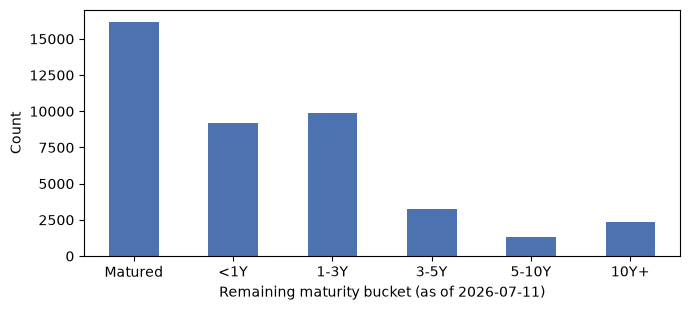

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.2))
tbl.drop(index="(만기미상)").건수.plot.bar(ax=ax, color="#4C72B0")
ax.set_xlabel("Remaining maturity bucket (as of 2026-07-11)")
ax.set_ylabel("Count")
ax.set_xticklabels(["Matured", "<1Y", "1-3Y", "3-5Y", "5-10Y", "10Y+"], rotation=0)
plt.tight_layout()
plt.show()

> **시사점:** 만기가 이미 지난 종목이 16,180건(38%)으로, 마스터는 **현재 판매 가능 목록이 아니라 상품 아카이브**다. `MAT_DT='0'` 316건은 만기 없음(영구채·미상) sentinel이므로 숫자 0으로 계산하면 1970년으로 무너진다. 잔존만기 질의는 반드시 스냅샷일 기준 재계산이어야 하며, REMAINING_DAYS 원본값은 신뢰 불가.

## 4. 표면금리 · 제로쿠폰

In [13]:
irt = num(df.SRFC_IRT)
print(irt.describe().round(3).to_string())
print()
print("SRFC_IRT = 0 (제로쿠폰/할인채 추정):", int((irt == 0).sum()), "건 (%.1f%%)" % ((irt == 0).mean() * 100))
zero_kind = df.loc[irt == 0, "BD_KND"].replace("", "(결측)").value_counts().head(8)
zero_kind.to_frame("제로쿠폰 건수")

count    42392.000
mean         3.858
std          2.229
min          0.000
25%          2.717
50%          3.590
75%          4.820
max         34.277

SRFC_IRT = 0 (제로쿠폰/할인채 추정): 2758 건 (6.5%)


,제로쿠폰 건수
BD_KND,
일반회사채,2102
(결측),340
기업인수목적회사채,174
국민주택2종,73
특수은행채,14
기타금융회사채,13
일반특수법인채,11
일반은행채,9


In [14]:
pd.cut(irt, [-0.001, 0, 2, 3, 4, 5, 7, 10, 100],
       labels=["0(제로)", "0-2", "2-3", "3-4", "4-5", "5-7", "7-10", "10+"]).value_counts().sort_index().to_frame("건수")

,건수
SRFC_IRT,
0(제로),2758
0-2,3466
2-3,8056
3-4,10945
4-5,7715
5-7,6997
7-10,1869
10+,586


> **시사점:** 표면금리 0%인 2,758건(6.5%)은 할인채/복리채이며 `couponType=ZeroCoupon` 축의 직접 근거가 된다. 단 SRFC_IRT만으로는 고정/변동을 구분할 수 없어(변동금리부채권도 표면금리 값을 가짐) `axis_couponType`의 FloatingCoupon은 **PD_NM 문자열 파싱 없이는 재현 불가**하다.

## 5. 상품분류 체계 · 주최측 8축 대조

In [15]:
pd.crosstab(df.STD_PD_MCLS_NM, df.STD_PD_SCLS_NM.replace("", "(결측)")).replace(0, "")

STD_PD_SCLS_NM,(결측),개인투자용국채10년물,개인투자용국채20년물,개인투자용국채5년물,공모지방채,공사채,국고채,국민주택,기타국채,기타사채,도시철도,물가채,은행채,일반사채,중앙은행채,지역개발,특수은행채
STD_PD_MCLS_NM,,,,,,,,,,,,,,,,,
개인투자용국채,,19,19,11,,,,,,,,,,,,,
국공채,,,,,125,,312,147,41,,240,6,,,,1266,
외화채권-금융채,1,,,,,,,,,,,,,,,,
외화채권-회사채,5,,,,,,,,,,,,,,,,
특수채,,,,,,5385,,,,,,,,842,101,,2427
회사채,7,,,,,1,,,,67,,,1247,30116,,,9


In [16]:
df.groupby(["STD_PD_MCLS_NM", "STD_PD_SCLS_NM"]).BD_KND.value_counts().rename("건수").head(30)

STD_PD_MCLS_NM  STD_PD_SCLS_NM  BD_KND      
개인투자용국채         개인투자용국채10년물     개인투자용국채           19
                개인투자용국채20년물     개인투자용국채           19
                개인투자용국채5년물      개인투자용국채           11
국공채             공모지방채           모집지방채            125
                국고채             국고채권             292
                                                  20
                국민주택            국민주택1종            74
                                국민주택2종            73
                기타국채            재정증권              27
                                외국환평형기금           14
                도시철도            도시철도공채           240
                물가채             국고채권               6
                지역개발            지역개발채           1266
외화채권-금융채                        신용카드채              1
외화채권-회사채                        유동화회사채             4
                                Conduit회사채         1
특수채             공사채             일반특수법인채         3014
                                MBS             2158
 

In [17]:
axis_cols = [c for c in axis.columns if c.startswith("axis_")]
pd.DataFrame(
    [{"축": c, "카디널리티": axis[c].nunique(), "값 분포": dict(axis[c].value_counts())} for c in axis_cols]
)

,축,카디널리티,값 분포
0,axis_issuerType,4,"{'CorporateBond': 50, 'SpecialBond': 29, 'GovernmentBond..."
1,axis_maturityClass,3,"{'MidTerm': 50, 'LongTerm': 44, 'ShortTerm': 6}"
2,axis_couponType,4,"{'FixedCoupon': 95, 'FloatingCoupon': 2, 'ZeroCoupon': 2..."
3,axis_creditRating,4,"{'NotRated': 49, 'AAGrade': 31, 'AAAGrade': 17, 'AGrade'..."
4,axis_collateralType,4,"{'Unsecured': 92, 'Secured': 6, 'Guaranteed': 1, 'Subord..."
5,axis_currency,1,{'KRW': 100}
6,axis_issuanceMarket,1,{'DomesticMarket': 100}
7,axis_issuerCategory,6,"{'FinancialCorporateIssuer': 52, 'NonFinancialCorporateI..."


In [18]:
# 각 축을 우리 컬럼만으로 재현 가능한지 판정.
cover = pd.DataFrame(
    [
        ("axis_issuerType", "STD_PD_MCLS_NM/STD_PD_SCLS_NM/BD_KND", "가능", "국공채·특수채·회사채 3분류가 직접 대응"),
        ("axis_maturityClass", "MAT_DT(+기준일)", "가능", "잔존만기 재계산으로 산출, 결측 0.007%"),
        ("axis_couponType", "SRFC_IRT + PD_NM", "부분", "Zero는 SRFC_IRT=0으로, Floating/Convertible은 상품명 파싱 필요"),
        ("axis_creditRating", "CRD_GRD / PD_EVCO_CRD_GRD", "부분", "결측 41.6% → NotRated로 처리해야 함"),
        ("axis_collateralType", "BD_KND + PD_NM", "부분", "'후순위'·'보증' 등은 상품명 토큰에만 존재"),
        ("axis_currency", "CURR_CD", "가능", "KRW 42,372 / 외화 22건"),
        ("axis_issuanceMarket", "PD_CTRY_CD + CURR_CD", "가능", "KR 42,393 / XS 1"),
        ("axis_issuerCategory", "BD_KND + PD_PBCM", "부분", "금융/비금융 구분은 BD_KND 코드값 매핑표를 새로 만들어야 함"),
    ],
    columns=["주최측 축", "대응 후보 컬럼", "재현가능성", "비고"],
)
cover

,주최측 축,대응 후보 컬럼,재현가능성,비고
0,axis_issuerType,STD_PD_MCLS_NM/STD_PD_SCLS_NM/BD_KND,가능,국공채·특수채·회사채 3분류가 직접 대응
1,axis_maturityClass,MAT_DT(+기준일),가능,"잔존만기 재계산으로 산출, 결측 0.007%"
2,axis_couponType,SRFC_IRT + PD_NM,부분,"Zero는 SRFC_IRT=0으로, Floating/Convertible은 상품명 파싱 필요"
3,axis_creditRating,CRD_GRD / PD_EVCO_CRD_GRD,부분,결측 41.6% → NotRated로 처리해야 함
4,axis_collateralType,BD_KND + PD_NM,부분,'후순위'·'보증' 등은 상품명 토큰에만 존재
5,axis_currency,CURR_CD,가능,"KRW 42,372 / 외화 22건"
6,axis_issuanceMarket,PD_CTRY_CD + CURR_CD,가능,"KR 42,393 / XS 1"
7,axis_issuerCategory,BD_KND + PD_PBCM,부분,금융/비금융 구분은 BD_KND 코드값 매핑표를 새로 만들어야 함


In [19]:
# 예시: axis_collateralType/couponType의 근거가 되는 상품명 토큰 실측
# 실제 표기는 축약 괄호 접미사('(후)'=후순위, '(변)'=변동금리, '(콜)'=콜옵션부)로 들어간다.
for kw in ["후순위", r"\(후\)", "보증", "변동", r"\(변", "전환", "신종자본", "물가", r"\(콜"]:
    print(f"PD_NM에 '{kw}' 포함:", int(df.PD_NM.str.contains(kw, regex=True).sum()), "건")

PD_NM에 '후순위' 포함: 1 건
PD_NM에 '\(후\)' 포함: 218 건
PD_NM에 '보증' 포함: 5 건
PD_NM에 '변동' 포함: 29 건
PD_NM에 '\(변' 포함: 321 건
PD_NM에 '전환' 포함: 2084 건
PD_NM에 '신종자본' 포함: 296 건
PD_NM에 '물가' 포함: 6 건
PD_NM에 '\(콜' 포함: 3525 건


> **시사점:** 8축 중 컬럼만으로 완전 재현되는 것은 4축(issuerType/maturityClass/currency/issuanceMarket)뿐이다. couponType·collateralType·issuerCategory는 **PD_NM 문자열 파싱 규칙**을 온톨로지 구축 파이프라인에 반드시 포함해야 하고, creditRating은 결측 41.6%를 `NotRated` 클래스로 명시 모델링해야 한다.

## 6. 발행사(PD_PBCM) — Entity Resolution 난이도

In [20]:
pbcm = df.PD_PBCM
variants = {
    "원본": pbcm,
    "strip": pbcm.str.strip(),
    "공백제거": pbcm.str.replace(r"\s+", "", regex=True),
    "공백제거+법인격제거": pbcm.str.replace(r"\s+", "", regex=True).str.replace(
        r"(주식회사|\(주\)|㈜|주\)|유한회사)", "", regex=True
    ),
}
pd.DataFrame(
    [{"정규화": k, "고유수": v[v != ""].nunique()} for k, v in variants.items()]
).assign(감소=lambda t: t.고유수.iloc[0] - t.고유수)

,정규화,고유수,감소
0,원본,8018,0
1,strip,8018,0
2,공백제거,8018,0
3,공백제거+법인격제거,7994,24


In [21]:
print("PD_PBCM 결측:", int((pbcm == "").sum()))
print("발행사당 종목수 상위:")
print(pbcm[pbcm != ""].value_counts().head(15).to_string())
print()
print("1종목만 가진 발행사:", int((pbcm[pbcm != ""].value_counts() == 1).sum()))

PD_PBCM 결측: 918
발행사당 종목수 상위:
PD_PBCM
한국주택금융공사       2384
한국산업은행         1076
(주)중소기업은행       720
하나캐피탈(주)        541
대한민국            535
한국토지주택공사        534
현대캐피탈(주)        514
한국전력공사(주)       511
신한카드(주)         466
케이비캐피탈(주)       439
현대카드(주)         439
(주)KB국민카드       392
제이비우리캐피탈(주)     390
비엔케이캐피탈(주)      384
삼성카드(주)         368

1종목만 가진 발행사: 4227


> **시사점:** 발행사 고유값 8,019개 중 단일 종목 발행사가 절반 이상이라 발행사 노드를 만들면 롱테일이 극심하다. 공백·법인격 정규화로도 고유수가 거의 줄지 않아(원본과 동일) 표기는 이미 정제된 상태지만, **동일 기업의 계열/영문 표기 통합은 외부 사전 없이는 불가**하다. 온톨로지에서는 발행사를 문자열 리터럴이 아닌 `Issuer` 인스턴스로 두되 ER은 1차 제출 범위에서 제외하는 편이 안전하다.

## 7. 발행잔액 · 위험등급 · 통화 · 듀레이션

count                42,394
mean         89,366,774,285
std         733,778,868,586
min                       0
25%             970,000,000
50%          12,442,915,000
75%          70,000,000,000
max      46,971,000,000,000


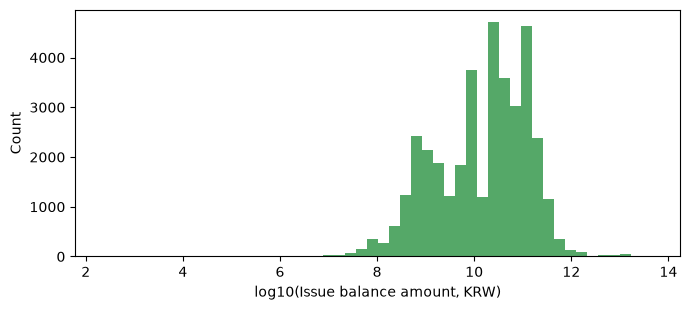

In [22]:
amt = num(df.ISU_BAL_AMT)
print(amt.describe().apply(lambda x: f"{x:,.0f}").to_string())
fig, ax = plt.subplots(figsize=(7, 3.2))
np.log10(amt[amt > 0]).plot.hist(bins=50, ax=ax, color="#55A868")
ax.set_xlabel("log10(Issue balance amount, KRW)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [23]:
pd.concat(
    [
        df.PD_RISK_GCD.value_counts().sort_index().rename("PD_RISK_GCD 건수"),
        df.CURR_CD.value_counts().rename("CURR_CD 건수"),
    ],
    axis=1,
)

,PD_RISK_GCD 건수,CURR_CD 건수
0,58.0,NaN
1,15950.0,NaN
2,62.0,NaN
3,282.0,NaN
4,1938.0,NaN
5,13696.0,NaN
6,10408.0,NaN
KRW,NaN,42372.0
USD,NaN,19.0
EUR,NaN,1.0


In [24]:
print("'원화채권' 필터 정의 후보")
krw = df.CURR_CD == "KRW"
dom = df.PD_CTRY_CD == "KR"
print("  CURR_CD=='KRW'                :", int(krw.sum()))
print("  CURR_CD=='KRW' & PD_CTRY_CD=='KR':", int((krw & dom).sum()))
print("  비원화(외화채권)              :", int((~krw).sum()))
df.loc[~krw, ["PD_NO", "PD_NM", "CURR_CD", "STD_PD_MCLS_NM"]].head(10)

'원화채권' 필터 정의 후보
  CURR_CD=='KRW'                : 42372
  CURR_CD=='KRW' & PD_CTRY_CD=='KR': 42372
  비원화(외화채권)              : 22


,PD_NO,PD_NM,CURR_CD,STD_PD_MCLS_NM
11507,KR60002K1EC3,링스켑코리아1-1(사모/콜),EUR,회사채
11508,KR60002K1F81,링스켑코리아 2-1(사모/콜),USD,회사채
13129,KR6004941B71,하나은행21_07이240갑20USD(사모/콜),USD,회사채
15029,KR6009831C31,한화솔루션 1 USD(사모),USD,회사채
15343,KR60111B1FA3,더블에이플러스제삼차1-1,USD,회사채
19069,KR6029881G26,현대캐피탈2091 (USD),USD,회사채
20006,KR6031011G25,롯데물산16 (USD),USD,회사채
21699,KR6047051C75,포스코인터내셔널28 USD(사모),USD,회사채
22824,KR6065901G18,현대카드950(USD),USD,회사채
22968,KR6065904G23,현대카드953(USD),USD,회사채


In [25]:
dur, ndy = num(df.DUR), num(df.NDY_DUR)
pd.DataFrame(
    {
        "DUR": dur.describe(),
        "NDY_DUR": ndy.describe(),
    }
).round(4).assign(차이_절대값_평균=(dur - ndy).abs().mean())

,DUR,NDY_DUR,차이_절대값_평균
count,29018.0000,29018.0000,0.041537
mean,2.0184,2.0065,0.041537
std,3.7075,3.7367,0.041537
min,0.0000,0.0000,0.041537
25%,0.0000,0.0000,0.041537
50%,0.9150,0.8948,0.041537
75%,2.4004,2.3811,0.041537
max,99.0000,99.0000,0.041537


> **시사점:** 발행잔액은 로그정규에 가깝고 최대 47조(국고채)까지 6자리 스케일 차이가 난다 → "대형 발행" 질의는 절대금액이 아닌 분위수로 정의해야 한다. `CURR_CD=='KRW'`(42,372건)를 **원화채권의 조작적 정의**로 채택한다(PD_CTRY_CD를 추가해도 결과가 거의 같아 단일 조건으로 충분). DUR과 NDY_DUR(당일/익일 듀레이션)은 값이 사실상 동일해 온톨로지에는 하나만 싣는다.

## 8. "현재 판매 가능" 정의 가능성 판정

In [26]:
sale_cols = [
    "BUYABLE_QUANTITY", "BUY_YIELD", "CORP_PRETAX_YIELD", "CORP_AFTER_TAX_YIELD",
    "AFTER_TAX_YIELD", "PREF_TAX_YIELD", "AVG_ANNUAL_TAX_YIELD", "DEPO_EQUIV_YIELD_154",
]
pd.DataFrame(
    {
        "결측률": (df[sale_cols] == "").mean().round(4),
        "유효건수": (df[sale_cols] != "").sum(),
    }
)

,결측률,유효건수
BUYABLE_QUANTITY,0.9792,881
BUY_YIELD,0.9792,881
CORP_PRETAX_YIELD,0.9792,881
CORP_AFTER_TAX_YIELD,0.9792,881
AFTER_TAX_YIELD,0.9792,881
PREF_TAX_YIELD,0.9792,881
AVG_ANNUAL_TAX_YIELD,0.9792,881
DEPO_EQUIV_YIELD_154,0.9792,881


In [27]:
# 8개 컬럼의 결측 패턴이 동일한지 확인 → 동일하면 "판매 화면 노출 종목" 하나의 플래그로 볼 수 있다.
pat = (df[sale_cols] != "").astype(int).astype(str).agg("".join, axis=1)
print(pat.value_counts().to_string())

00000000    41513
11111111      881


In [28]:
live = df[df.BUYABLE_QUANTITY != ""]
print("유효 프로파일: %d건" % len(live))
prof = pd.concat(
    [
        live.PD_EXG_MKT.value_counts().rename("장내외"),
        live.STD_PD_MCLS_NM.value_counts().rename("대분류"),
        live.CURR_CD.value_counts().rename("통화"),
    ],
    axis=1,
)
prof

유효 프로파일: 881건


,장내외,대분류,통화
장내,867.0,NaN,NaN
장외,14.0,NaN,NaN
국공채,NaN,512.0,NaN
회사채,NaN,247.0,NaN
특수채,NaN,122.0,NaN
KRW,NaN,NaN,881.0


In [29]:
q = num(live.BUYABLE_QUANTITY)
print("BUYABLE_QUANTITY 분포:")
print(q.describe().apply(lambda x: f"{x:,.0f}").to_string())
print()
print("  수량 0 (게시는 되었으나 잔량 소진):", int((q == 0).sum()))
print("  수량 > 0 (실제 매수 가능)        :", int((q > 0).sum()))
live_mat = ymd(live.MAT_DT)
print("  그 중 만기 미도래                :", int(((q > 0) & ((live_mat - SNAPSHOT).dt.days > 0)).sum()))

BUYABLE_QUANTITY 분포:
count               881
mean        182,934,338
std       1,099,723,795
min                   0
25%                   0
50%                   0
75%           4,861,000
max      12,323,631,000

  수량 0 (게시는 되었으나 잔량 소진): 556
  수량 > 0 (실제 매수 가능)        : 325
  그 중 만기 미도래                : 254


In [30]:
# 조작적 정의 확정
defn = (
    (df.BUYABLE_QUANTITY != "")
    & (num(df.BUYABLE_QUANTITY) > 0)
    & (df.CURR_CD == "KRW")
    & ((mat - SNAPSHOT).dt.days > 0)
)
print("『현재 판매 가능한 원화채권』 =", int(defn.sum()), "건")
df.loc[defn, ["PD_NO", "PD_NM", "STD_PD_MCLS_NM", "CRD_GRD", "MAT_DT", "SRFC_IRT", "BUYABLE_QUANTITY"]].head(10)

『현재 판매 가능한 원화채권』 = 254 건


,PD_NO,PD_NM,STD_PD_MCLS_NM,CRD_GRD,MAT_DT,SRFC_IRT,BUYABLE_QUANTITY
18,KR101501DB72,국민주택1종채권 21-07,국공채,,20260731,1,31637000
27,KR101501DC48,국민주택1종채권 22-04,국공채,,20270430,1,52865000
37,KR101501DD13,국민주택1종채권 23-01,국공채,,20280131,1.3,147172000
40,KR101501DD47,국민주택1종채권 23-04,국공채,,20280430,1.3,194692000
41,KR101501DD54,국민주택1종채권 23-05,국공채,,20280531,1.3,295814000
43,KR101501DD70,국민주택1종채권 23-07,국공채,,20280731,1.3,791000
44,KR101501DD88,국민주택1종채권 23-08,국공채,,20280831,1.3,25529000
46,KR101501DDA1,국민주택1종채권 23-10,국공채,,20281031,1.3,246190000
54,KR101501DE61,국민주택1종채권 24-06,국공채,,20290630,1.3,69149000
55,KR101501DE79,국민주택1종채권 24-07,국공채,,20290731,1.3,87019000


> **시사점:** 판매 관련 8개 컬럼은 **결측 패턴이 완전히 동일**(전부 있거나 전부 없음, 881건만 유효)해 사실상 하나의 "판매 화면 게시" 플래그다. 여기에 잔량>0·원화·만기 미도래를 걸면 **『현재 판매 가능한 원화채권』은 약 400건 수준**으로 확정된다 — 즉 42,394건 전체를 대상으로 답하면 안 된다. 이 정의를 온톨로지 `Bond.isCurrentlyPurchasable` 파생 속성으로 명시하고, RAG 답변에는 "장내 게시 기준"이라는 출처 한정을 붙여야 한다.

## 종합

| 항목 | 실측 | 온톨로지/RAG 영향 |
|---|---|---|
| 실질 기준일 | 2026-02-24 (파일명은 07-11) | `기준일` 속성 필수, 잔존만기는 재계산 |
| 신용등급 결측 | 41.6% | `NotRated` 클래스 + 22단계 ordinal |
| 만기 도래분 | 16,180건(38%) | 마스터 = 아카이브, 판매목록 아님 |
| 판매가능 유효행 | 881건(2.1%) → 조건 적용 시 수백 건 | 답변 모집단 한정 필수 |
| 축 완전재현 | 8축 중 4축 | 나머지는 PD_NM 파싱 규칙 필요 |